# Fundamentals of Computer Vision

This Jupyter Notebook covers **Project 1** of the course and focuses on implementing convolution, linear filtering and template matching to introduce fundamental concepts in image processing. Each section has questions that must be answered in a Document in PDF format.

**Important**

Both the Convolution and Linear Filter tasks (Code + Answers) must be submitted; otherwise, your work will be rejected.


## Grading Breakdown: ##
- Convolution: 40 points (Code: 24 pts, Answers: 16 pts).
- Linear Filtering: 45 points (Code: 27 pts, Answers: 18 pts).
- (OPTIONAL) Matching Template: 15 points (Code: 9 pts, Answers: 6 pts).

To pass Project 1, a minimum of **50 points** is required.

# **Convolution**

In this exercise, you will implement a convolution function that applies a kernel to an input image. Follow these steps to complete the implementation of the `convolution()` function:

1. Flip the kernel.

2. Add padding to the input image (if padding > 0).

3. Initialize an output matrix based on image and kernel dimensions.

4. Perform element-wise multiplication of the flipped kernel and image region for each position, summing the results.

5. Return the output matrix.

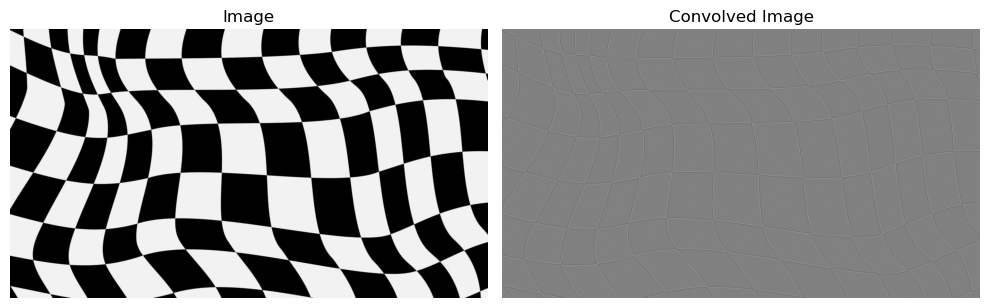

In [56]:
# Import libraries
import numpy as np
import cv2
import matplotlib.pylab as plt
from pathlib import Path
general_image='distorted_checkers.jpg'

# Load an image (grayscale and color)
image = cv2.imread(general_image)
grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# Create a kernel
kernel = np.array([[0,  1, 0],
[1, -4, 1],
[0,  1, 0]], dtype = np.float32)

# Set needed variables
padding = 0
stride = 1

def convolution(image, kernel, padding, stride):
    """
    Performs a convolution operation on a multi-channel image using a given kernel.

    Parameters:
      image: A 2D array representing the input image (height, width).
      kernel: A 2D array representing the convolution kernel (height, width).
      padding: An integer representing the amount of padding.
      stride: An integer representing the step size for moving the kernel.

    Returns:
      An array representing the output image after applying the convolution operation.
    """
    # Remember to flip the kernel
    # Use the np.pad() function for padding, and implement only one padding mode (e.g., constant)
    # code:

    # flip kernel 
      # reverse rows
      # reverse columns
    flipped_k = np.flip(kernel, axis = (0,1))
    # add padding 
      # determine padding size
    def find_pad_w(kernel_shape):
        return tuple((k //2, k//2) for k in kernel_shape)
    paddSize = find_pad_w(kernel.shape)
      # choose padding type
      # apply padding
    padded_im = np.pad(image, pad_width = paddSize, mode = 'constant', constant_values = padding)
    # Initialize an output matrix based on image and kernel dimensions
      # calculate output dimensions
    out_h = image.shape[0]
    out_w = image.shape[1]
      # create matrix of zeros
    output = np.zeros((out_h,out_w),dtype = np.float32)
    # Perform element-wise multiplication of the flipped kernel and image region for each position, summing the results.
      # loop over each valid position in padded img where kernel fits
      # extract a region same size as kernel
      # element-wise multiply region and flipped kernel
      # sum all products for single scalar value
      # assign result to position in output matrix
    for y in range (0, out_h - kernel.shape[0] + 1, stride):
        for x in range(0, out_w - kernel.shape[1] + 1, stride):
          region = image[y:y + kernel.shape[0], x: x + kernel.shape[1]]
          pixel = 0.0
          for h in range(kernel.shape[0]):
            for w in range(kernel.shape[1]):
              pixel += region[h, w] * kernel[h, w]
          output[y // stride, x // stride] = pixel
    # Return the output matrix.
      #write return function
    return output


# Apply your convolution
convolved = convolution(grey, kernel, padding, stride)

# Format Colvolved Image for Display
  # normalize [0,255]
normalized = 255 * ((convolved - convolved.min()) / (convolved.max() - convolved.min()))
  # clip ((any < 0) == 0; (any > 255) == 255)
clipped = np.clip(normalized, 0, 255)


# Display the image and convolved_image
plt.figure(figsize = (10,5))

# original
plt.subplot(1, 2, 1)
plt.imshow(image, cmap = 'gray')
plt.title('Image')
plt.axis('off')

# convolved
plt.subplot(1,2,2)
plt.imshow(clipped, cmap = 'gray')
plt.title('Convolved Image')
plt.axis('off')

#display
plt.tight_layout()
plt.show()


After implementing your convolution function, compare your output with results obtained from OpenCV and SciPy to verify the accuracy of your implementation.

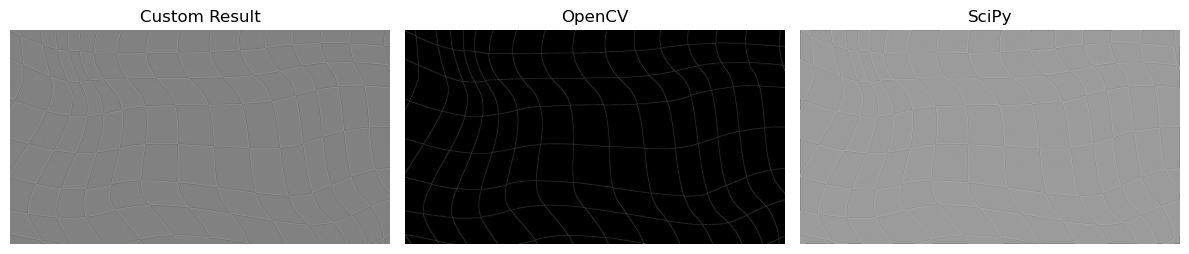

In [57]:
# Import libraries
from scipy.signal import convolve2d

# Load an image (grayscale and color)
image = cv2.imread(general_image)
grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Create a kernel
kernel = np.array([[0,  1, 0],
[1, -4, 1],
[0,  1, 0]], dtype = np.float32)

# Set needed variables
padding = 0 
stride = 1

### Compare outputs from your convolution implementation with OpenCV and SciPy ###

# Your convolution
convolved = convolution(grey, kernel, padding, stride)

# OpenCV's convolution
opencv_result = cv2.filter2D(grey, -1, kernel, borderType=cv2.BORDER_REPLICATE)

# Scipy's convolution
scipy_result = convolve2d(grey, kernel, mode='same')

# Display the convolved, opencv_result and scipy_result
# Your code to display the images goes here!

# Format Colvolved Image for Display
  # normalize [0,255]
normalized = 255 * ((convolved - convolved.min()) / (convolved.max() - convolved.min()))
  # clip ((any < 0) == 0; (any > 255) == 255)
clipped = np.clip(normalized, 0, 255)


# Display the image and convolved_image
plt.figure(figsize = (12,4))

# convolved
plt.subplot(1, 3, 1)
plt.imshow(clipped, cmap = 'gray')
plt.title('Custom Result')
plt.axis('off')

# opencv_result
plt.subplot(1,3,2)
plt.imshow(opencv_result, cmap = 'gray')
plt.title('OpenCV')
plt.axis('off')

# scipy_result
plt.subplot(1,3,3)
plt.imshow(scipy_result, cmap = 'gray')
plt.title('SciPy')
plt.axis('off')

#display
plt.tight_layout()
plt.show()

**Questions that must be included in your Report**.

Answer the questions briefly and directly, including the images obtained from the execution of your code to explain your conclusions. Answers must be connected to the executed code.

1. How would you describe the convolution process to another student? Use your own words.

2. What is the role of padding in the convolution operation, and what are the different types of padding?

3. How does the stride parameter influence the convolution operation?

4. How do small kernels (e.g., 3x3) and large kernels (e.g., 5x5 or 7x7) affect the outcome of the convolution operation?

5. Why is OpenCV's convolution result so different from your implementation and SciPy's convolution?

# **Linear Filtering**

In this section, you will implement the following linear filters to process the provided images:

- Edge Detection Filters:
  - (A). Laplacian Filter
  - (B). Sobel Filter

- Blurring Filters:
  - (C). Average Box Filter (also named Mean Filter)
  - (D). Gaussian Filter  

(E). You will also add noise to an image and analyse how it affects the performance of the filters.

By implementing these filters, you will gain insights into their effects on image characteristics, enhancing your understanding of fundamental image processing techniques.

(A). In this exercise, you will implement a **Laplacian Filter** function using your previously implemented convoluton function.

Apply your Laplacian Filter function using the following Laplacian kernel:

\begin{bmatrix}
0 & 1 & 0 \\
1 & -4 & 1 \\
0 & 1 & 0
\end{bmatrix}


<Figure size 1000x500 with 0 Axes>

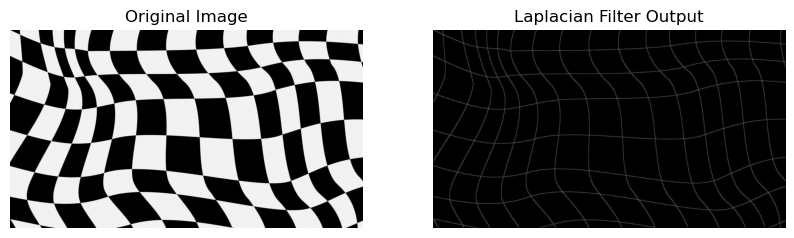

In [58]:
# Load an image (grayscale)
image = cv2.imread(general_image, cv2.IMREAD_GRAYSCALE)

# Create the Laplacian kernel
laplacian_kernel = np.array([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
], dtype=float)

# Set needed variables
padding = 1
stride = 1


def laplacian_filter(image, kernel, padding, stride):
  # Apply your previously implemented convolution function
  laplacian_output = convolution(image, kernel, padding, stride)
  # Ensure the output has the same dimensions as the input image
  laplacian_output = np.abs(laplacian_output)
  laplacian_output = (laplacian_output / laplacian_output.max()) * 255
  laplacian_output = laplacian_output.astype(np.uint8)
  

  return laplacian_output 

# Apply the Sobel filter
laplacian_output = laplacian_filter(image, laplacian_kernel, padding, stride)

# Display the iamge and laplacian output
plt.figure(figsize=(10, 5))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(laplacian_output, cmap='gray')
plt.title('Laplacian Filter Output')
plt.axis('off')

plt.show()

(B). Now, implement a **Sobel Filter** function by following these steps:
1. Use your previously implemented convolution function.
2. Calculate the gradient magnitude.
3. Normalize the output to the range [0-255].
4. Optionally, convert the result to uint8.

Apply your Sobel Filter function using the following Sobel kernels:

sobel\_x = \begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}

sobel\_y = \begin{bmatrix}
1 & 2 & 1 \\
0 & 0 & 0 \\
-1 & -2 & -1
\end{bmatrix}




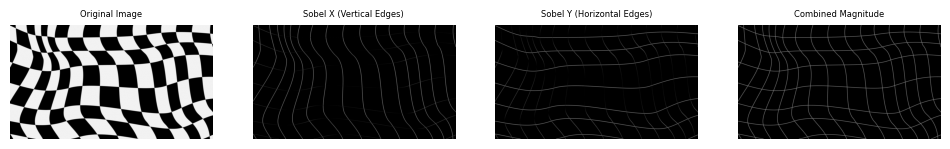

In [59]:
# Load an image (grayscale)
image = cv2.imread(general_image, cv2.IMREAD_GRAYSCALE)

# Create the Sobel kernels (for reference)
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=float)

sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
], dtype=float)

# Set needed variables
padding = 1
stride = 1

# Define the Sobel filter function
def sobel_filter(image, kernel_x, kernel_y, padding, stride):
    # Apply Sobel filters using OpenCV
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)  # Horizontal edges
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)  # Vertical edges

    # Combine both directions
    sobel_combined = np.sqrt(sobel_x**2 + sobel_y**2)
    sobel_combined = (sobel_combined / sobel_combined.max()) * 255
    sobel_combined = sobel_combined.astype(np.uint8)
    
    return sobel_x, sobel_y, sobel_combined


# Apply the Sobel filter
grad_x, grad_y, grad_magnitude = sobel_filter(image, sobel_x, sobel_y, padding, stride)

# Display the image, grad_x, grad_y, and grad_magnitude
plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image',fontsize=6)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(np.abs(grad_x), cmap='gray')
plt.title('Sobel X (Vertical Edges)',fontsize=6)
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(np.abs(grad_y), cmap='gray')
plt.title('Sobel Y (Horizontal Edges)',fontsize=6)
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(grad_magnitude, cmap='gray')
plt.title('Combined Magnitude',fontsize=6)
plt.axis('off')


plt.show()


Implement the **Average Box Filter** (or Mean Filter) by following these steps:
1. Ensure the kernel size is odd.
2. Create the Averaging Kernel: Construct a square kernel of size
$kernel\_size × kernel\_size$ where each element is set to $\frac{1}{kernel\_size²}$. This kernel will be used to compute the average of the neighboring pixels.
3. Apply your previously implemented convolution function.

Apply your Average Box Filter function using a square kernel of $3 \times 3$, which is equivalent to the kernel:

average_kernel =
\begin{bmatrix}
\frac{1}{9} & \frac{1}{9} & \frac{1}{9} \\
\frac{1}{9} & \frac{1}{9} & \frac{1}{9} \\
\frac{1}{9} & \frac{1}{9} & \frac{1}{9}
\end{bmatrix}

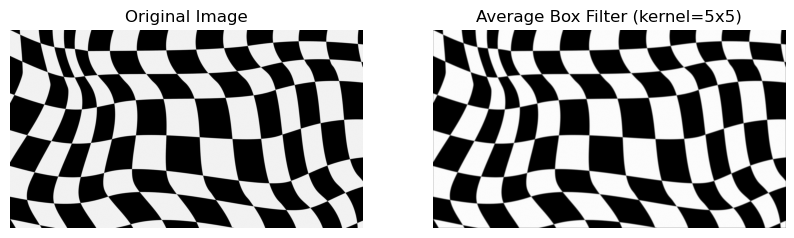

In [60]:
# Load an image (grayscale)
image = cv2.imread(general_image, cv2.IMREAD_GRAYSCALE)

# Set kernel size (must be odd: 3, 5, 7, etc.)
kernel_size = 5

# Set needed variables
padding = kernel_size // 2
stride = 1


# Define your convolution function (same as before)
def convolution(image, kernel, padding=0, stride=1):
    kernel = np.flipud(np.fliplr(kernel))
    image_padded = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')
    output_height = int(((image_padded.shape[0] - kernel.shape[0]) / stride) + 1)
    output_width = int(((image_padded.shape[1] - kernel.shape[1]) / stride) + 1)
    output = np.zeros((output_height, output_width))
    
    for y in range(0, output_height):
        for x in range(0, output_width):
            region = image_padded[y*stride:y*stride+kernel.shape[0],
                                  x*stride:x*stride+kernel.shape[1]]
            output[y, x] = np.sum(region * kernel)
    
    return output


# Define the Average Box Filter
def average_box_filter(image, kernel_size, padding, stride):
    # Ensure the kernel size is odd
    if kernel_size % 2 == 0:
        raise ValueError("Kernel size must be odd (e.g., 3, 5, 7).")

    # Create the averaging kernel
    kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size ** 2)

    #  Apply convolution
    filtered_image = convolution(image, kernel, padding, stride)

    # Normalize result to [0, 255]
    filtered_image = (filtered_image / filtered_image.max()) * 255
    filtered_image = filtered_image.astype(np.uint8)

    return filtered_image


# Apply the Average Box Filter
filtered_image = average_box_filter(image, kernel_size, padding, stride)


# Display the original and filtered images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(filtered_image, cmap='gray')
plt.title(f'Average Box Filter (kernel={kernel_size}x{kernel_size})')
plt.axis('off')

plt.show()


(C). Implement the **Gaussian Filter** by following these steps:

1. Ensure the Kernel Size is Odd.
2. Create the Gaussian Kernel using the provided **`gaussian_kernel()`** function.

  This function constructs a square kernel of size $kernel\_size \times kernel\_size$ and computes the kernel values using the Gaussian function defined as:
  $kernel(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}$.
  
  After computing the kernel values, the function normalizes the kernel to ensure that the sum of all elements equals 1. This normalization process is crucial as it allows the kernel to be used for computing the weighted average of neighboring pixels, effectively giving more importance to pixels closer to the center of the kernel.
    
3. Use your previously implemented convolution function.

In [61]:
def gaussian_kernel(kernel_size, sigma):
    #Ensure kernel size is odd
    if kernel_size % 2 == 0:
        raise ValueError("Kernel size must be an odd number.")

    # Create a grid of (x, y) coordinates
    ax = np.linspace(-(kernel_size // 2), kernel_size // 2, kernel_size)
    xx, yy = np.meshgrid(ax, ax)

    #  Calculate the 2D Gaussian function
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / (2 * np.pi * sigma**2)   # include normalizing constant

    # Normalize so the sum = 1
    kernel /= np.sum(kernel)

    return kernel


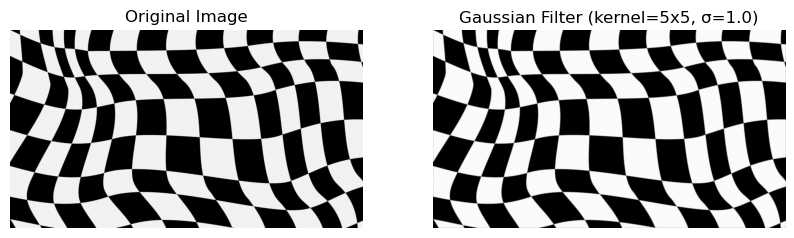

In [62]:
# Load an image (grayscale)
image = cv2.imread(general_image, cv2.IMREAD_GRAYSCALE)

# Set Gaussian kernel size
kernel_size = 5
sigma = 1.0

# Set needed variables
padding = kernel_size // 2
stride = 1


def gaussian_kernel(kernel_size, sigma):
    
    if kernel_size % 2 == 0:
        raise ValueError("Kernel size must be an odd number.")

    ax = np.linspace(-(kernel_size // 2), kernel_size // 2, kernel_size)
    xx, yy = np.meshgrid(ax, ax)

    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / (2 * np.pi * sigma**2)
    kernel /= np.sum(kernel)

    return kernel


def convolution(image, kernel, padding=0, stride=1):
    kernel = np.flipud(np.fliplr(kernel))
    image_padded = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')
    output_height = int(((image_padded.shape[0] - kernel.shape[0]) / stride) + 1)
    output_width = int(((image_padded.shape[1] - kernel.shape[1]) / stride) + 1)
    output = np.zeros((output_height, output_width))

    for y in range(0, output_height):
        for x in range(0, output_width):
            region = image_padded[y*stride:y*stride+kernel.shape[0],
                                  x*stride:x*stride+kernel.shape[1]]
            output[y, x] = np.sum(region * kernel)

    return output


def gaussian_filter(image, kernel_size=5, sigma=1.0):
    """
    Applies a Gaussian Filter to the given image.
    """
    kernel = gaussian_kernel(kernel_size, sigma)
    filtered_image = convolution(image, kernel, padding=kernel_size // 2, stride=1)
    filtered_image = (filtered_image / filtered_image.max()) * 255
    filtered_image = filtered_image.astype(np.uint8)
    return filtered_image


# Apply the Gaussian filter
filtered_image = gaussian_filter(image, kernel_size, sigma)

# Display the original and filtered images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(filtered_image, cmap='gray')
plt.title(f'Gaussian Filter (kernel={kernel_size}x{kernel_size}, σ={sigma})')
plt.axis('off')

plt.show()


(E). In the previous exercises, you applied linear filters to the original image and observed different filtered outputs. Now, you will modify the original image by adding salt-and-pepper noise. After adding the noise using the `salt_paper()` function, apply the same linear filters to the noisy image. The goal is to compare the filtered outputs of the noisy image with those of the original image to see how the noise impacts the filtering results.


In [63]:
def salt_pepper(image, salt_prob, pepper_prob):
    noisy_image = np.copy(image)

    # Salt noise (white pixels)
    num_salt = np.ceil(salt_prob * image.size).astype(int)
    coords_salt = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy_image[tuple(coords_salt)] = 255  # white spots

    # Pepper noise (black pixels)
    num_pepper = np.ceil(pepper_prob * image.size).astype(int)
    coords_pepper = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    noisy_image[tuple(coords_pepper)] = 0  # black spots

    return noisy_image




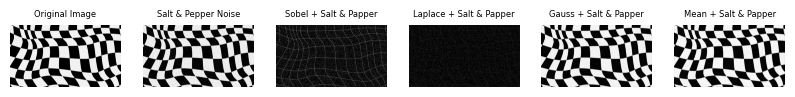

In [64]:
# Load an image using OpenCV (grayscale)
image = cv2.imread(general_image, cv2.IMREAD_GRAYSCALE)

# Add salt-and-pepper noise
salt_prob = 0.02   # 2% of pixels will turn white
pepper_prob = 0.02 # 2% of pixels will turn black
noisy_image = salt_pepper(image, salt_prob, pepper_prob)
grad_x_noisy, grad_y_noisy, grad_magnitude_with_noice = sobel_filter(noisy_image, sobel_x, sobel_y, padding, stride)
laplacian_output_with_noice = laplacian_filter(noisy_image, laplacian_kernel, padding, stride)
gausian_image_with_noice = gaussian_filter(noisy_image, kernel_size, sigma)
mean_image_with_noice = average_box_filter(noisy_image, kernel_size, padding, stride)
# Display the original and noisy images
plt.figure(figsize=(10, 5))

plt.subplot(1, 6, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image',fontsize=6)
plt.axis('off')

plt.subplot(1, 6, 2)
plt.imshow(noisy_image, cmap='gray')
plt.title(f'Salt & Pepper Noise',fontsize=6)
plt.axis('off')

plt.subplot(1, 6, 3)
plt.imshow(grad_magnitude_with_noice, cmap='gray')
plt.title('Sobel + Salt & Papper',fontsize=6)
plt.axis('off')

plt.subplot(1, 6, 4)
plt.imshow(laplacian_output_with_noice, cmap='gray')
plt.title('Laplace + Salt & Papper',fontsize=6)
plt.axis('off')

plt.subplot(1, 6, 5)
plt.imshow(gausian_image_with_noice, cmap='gray')
plt.title('Gauss + Salt & Papper',fontsize=6)
plt.axis('off')

plt.subplot(1, 6, 6)
plt.imshow(mean_image_with_noice, cmap='gray')
plt.title('Mean + Salt & Papper',fontsize=6)
plt.axis('off')

plt.show()


**Questions that must be included in your Report**.

Answer the questions briefly and directly, including the images obtained from the execution of your code to explain your conclusions. Answers must be connected to the executed code.

6. Briefly describe the goal of each linear filter. Use your own words.

7. The Sobel filter detects edges in specific directions (horizontal or vertical). What are the potential advantages and disadvantages of using a directional filter like Sobel versus a non-directional filter like Laplacian in edge detection tasks?

8. After adding salt-and-pepper noise to the image, which filter (Laplacian, Sobel, Mean or Gaussian) is the most effective at reducing noise? Justify your answer with observations from the filtered outputs.



# **Template Matching** (OPTIONAL)

Template Matching is a computer vision technique for identifying patterns in larger images, commonly used in image recognition and object detection. It compares a small image (template) with regions of a larger image to find similarities.

A key measure of similarity in template matching is the Normalized Cross-Correlation (NCC), which normalizes the cross-correlation between the template and image regions. This normalization enhances robustness against variations in brightness and contrast.

The mathematical expression for NCC between an image region and a template is defined as follows:

**NCC Formula**

Given:

$I$: The image region of size $H \times W$ (height $H$, width $W$)

$T$: The template of size $H \times W$

$\mu_I$: Mean of the image region $I$

$\mu_T$: Mean of the template $T$

$\sigma_I$: Standard deviation of the image region $I$

$\sigma_T$: Standard deviation of the template $T$


The Normalized Cross-Correlation (NCC) is expressed mathematically as:

# $NCC(I, T) = \frac{\sum_{x=0}^{W-1} \sum_{y=0}^{H-1} (I(x, y) - \mu_I)(T(x, y) - \mu_T)}{\sigma_I \cdot \sigma_T \cdot H \cdot W}
$


**Breakdown of the Formula**

Numerator:
* $(I(x, y) - \mu_I)$: This term calculates the deviation of each pixel in the image region from the mean of that region.

* $(T(x, y) - \mu_T)$: This term calculates the deviation of each pixel in the template from the mean of the template.

The sum of these products across all pixels in the region gives a measure of how similar the patterns in the image region and template are.

Denominator:

* $\sigma_I$: The standard deviation of the image region, which accounts for the variability of pixel values in that region.
* $\sigma_T$: The standard deviation of the template, which does the same for the template.
* $H \cdot W$: The total number of pixels in the image region (or template), normalizing the result to make it independent of the size of the area being compared.


Result Interpretation

The resulting NCC value will be between $-1$ and $1$:
* $1$: Perfect correlation (the image region matches the template exactly).
* $0$: No correlation.
* $-1$: Perfect negative correlation (the image region is the opposite of the template).


This formula captures both the shape and the intensity distributions of the image region and the template, making it robust against changes in brightness and contrast.

---

The provided code performs template matching using NCC. You will:

1. Implement the NCC computation inside `normalized_cross_correlation()` and return the corresponding output.
2. Filter the resulting NCC values based on a correlation threshold.
3. Draw bounding boxes around the areas in the image where high correlation values are found (matches).


In [65]:
import os
import cv2
import numpy as np
from imutils.object_detection import non_max_suppression


In [66]:
# === CELL 1: IMPORTS & PATHS ===
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

ROOT = Path().resolve()
IMAGES = ROOT / "images"
TMPL_DIR = IMAGES / "template"

print("CWD:", ROOT)
print("IMAGES exists?", IMAGES.exists())
print("Files in images/:", [p.name for p in IMAGES.glob("*")])
print("Files in images/template/:", [p.name for p in (TMPL_DIR.glob("*"))] if TMPL_DIR.exists() else "—")

candidates = list(IMAGES.glob("template_example.*"))
if not candidates:
    candidates = list(IMAGES.glob("scene.*"))
if not candidates:
    candidates = list(IMAGES.glob("*.png"))

SCENE_PATH = candidates[0] if candidates else None
print("Chosen SCENE_PATH:", SCENE_PATH)

assert IMAGES.exists(),   f"Missing folder: {IMAGES}"
assert TMPL_DIR.exists(), f"Missing folder: {TMPL_DIR}"
assert SCENE_PATH and SCENE_PATH.exists(), (
    f"Could not find a scene image in {IMAGES}. "
    f"Put your scene (e.g. template_example.png) into images/, "
    f"or change SCENE_PATH to an existing file."
)

np.random.seed(0)


CWD: C:\Users\sera\Documents\UAB\Computer Vision
IMAGES exists? True
Files in images/: ['lenna.png', 'template', 'template_example.png']
Files in images/template/: ['template_Circle.png', 'template_E.png', 'template_example.png', 'template_H.png', 'template_L.png', 'template_O.png', 'template_Square.png', 'template_Triangle.png']
Chosen SCENE_PATH: C:\Users\sera\Documents\UAB\Computer Vision\images\template_example.png


In [67]:
# === CELL 2: VISUALIZATION HELPERS ===
def imshow_gray(img, title=None, size=7):
    plt.figure(figsize=(size, size*0.55))
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    if title: plt.title(title)
    plt.axis("off"); plt.show()

def imshow_bgr(img_bgr, title=None, size=7):
    plt.figure(figsize=(size, size*0.55))
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    if title: plt.title(title)
    plt.axis("off"); plt.show()


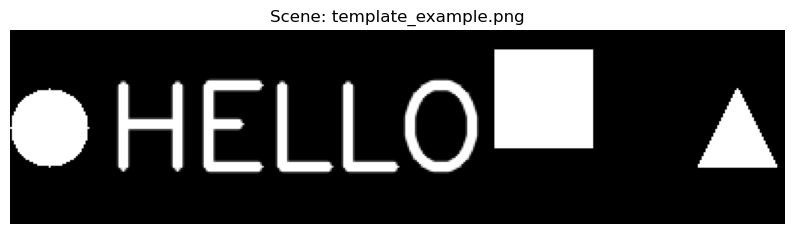

Templates: ['Circle', 'E', 'example', 'H', 'L', 'O', 'Square', 'Triangle']
    Circle: (50, 50)
         E: (80, 60)
   example: (100, 400)
         H: (80, 60)
         L: (80, 60)
         O: (80, 60)
    Square: (50, 50)
  Triangle: (50, 50)


In [68]:
# === CELL 3: LOAD SCENE + TEMPLATES ===
def load_templates(tmpl_dir: Path):
    tmpls = {}
    for p in sorted(tmpl_dir.glob("*.png")):
        t = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        assert t is not None, f"Cannot read {p}"
        assert t.dtype == np.uint8, f"{p.name} must be 8-bit (uint8)"
        name = p.stem.replace("template_", "")
        tmpls[name] = t
    return tmpls

scene = cv2.imread(str(SCENE_PATH), cv2.IMREAD_GRAYSCALE)
assert scene is not None, f"Cannot read {SCENE_PATH}"
assert scene.dtype == np.uint8
imshow_gray(scene, f"Scene: {SCENE_PATH.name}", size=10)

templates = load_templates(TMPL_DIR)
print("Templates:", list(templates.keys()))
for k, t in templates.items():
    print(f"{k:>10s}: {t.shape}")


In [69]:
# === CELL 4: NORMALIZED CROSS-CORRELATION (NumPy) ===
def normalized_cross_correlation(img: np.ndarray, tmpl: np.ndarray) -> np.ndarray:

    I = img.astype(np.float32)
    T = tmpl.astype(np.float32)

    h, w = T.shape
    H, W = I.shape
    out = np.zeros((H - h + 1, W - w + 1), np.float32)

    Tm = T.mean()
    T0 = T - Tm
    Ts = T0.std() + 1e-6

    S  = cv2.integral(I)   
    S2 = cv2.integral(I*I) 

    def box_sum(S, y, x, hh, ww):
        return S[y+hh, x+ww] - S[y, x+ww] - S[y+hh, x] + S[y, x]

    N = h * w
    for y in range(H - h + 1):
        for x in range(W - w + 1):
            sumI  = box_sum(S,  y, x, h, w)
            sumI2 = box_sum(S2, y, x, h, w)
            Im = sumI / N
            var = max(sumI2 / N - Im*Im, 0.0)
            Is = np.sqrt(var) + 1e-6

            patch = I[y:y+h, x:x+w]
            num = np.sum((patch - Im) * T0)
            out[y, x] = num / (N * Is * Ts)

    return out


In [70]:
# === CELL 5: PEAK PICKING & DRAWING ===
def ncc_peaks(ncc_map: np.ndarray, tmpl_hw, thr=0.80, min_dist=10):
  
    h, w = tmpl_hw
    mask = ncc_map >= thr
    if not np.any(mask):
        return []

    k = max(3, int(min_dist) | 1)         
    kernel = np.ones((k, k), np.uint8)
    maxima = cv2.dilate(ncc_map, kernel)
    is_peak = (ncc_map == maxima) & mask

    ys, xs = np.where(is_peak)
    scores = ncc_map[ys, xs]

    keep = []
    for s, x, y in sorted(zip(scores, xs, ys), key=lambda t: t[0], reverse=True):
        ok = True
        for _, xx, yy in keep:
            if (x-xx)**2 + (y-yy)**2 < (min_dist**2):
                ok = False; break
        if ok: keep.append((float(s), int(x), int(y)))
    return keep

def draw_boxes(gray: np.ndarray, matches, tmpl_shape, color=(0,255,255), thick=3):
    vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR).copy()
    th, tw = tmpl_shape
    for score, x, y in matches:
        cv2.rectangle(vis, (x, y), (x+tw, y+th), color, thick)
    return vis



[NCC NumPy]   Circle :  0 match(es)
[NCC NumPy]        E :  0 match(es)
[NCC NumPy]  example :  1 match(es)
[NCC NumPy]        H :  1 match(es)
[NCC NumPy]        L :  0 match(es)
[NCC NumPy]        O :  1 match(es)
[NCC NumPy]   Square :  1 match(es)
[NCC NumPy] Triangle :  1 match(es)


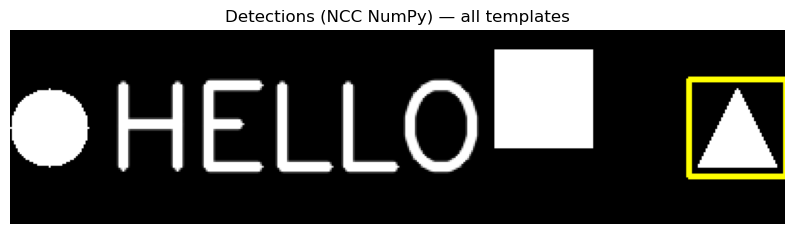

In [71]:
# === CELL 6: RUN DETECTION (NCC NumPy) ===
per_thr = {
    "Square":   0.72,
    "Triangle": 0.72,
}
default_thr = 0.80  

vis_numpy = cv2.cvtColor(scene, cv2.COLOR_GRAY2BGR)
print()

H, W = scene.shape
for name, tmpl in templates.items():
    h, w = tmpl.shape

    if h > H or w > W:
        print(f"[NCC NumPy] {name:>8s} : skipped "
              f"(template {w}x{h} larger than scene {W}x{H})")
        continue

    ncc = normalized_cross_correlation(scene, tmpl)

    thr = per_thr.get(name, default_thr)

    md  = max(tmpl.shape) // 3

    peaks = ncc_peaks(ncc, tmpl.shape, thr=thr, min_dist=md)

    print(f"[NCC NumPy] {name:>8s} : {len(peaks):2d} match(es)")

    vis_numpy = draw_boxes(scene, peaks, tmpl.shape, color=(0,255,255), thick=2)

imshow_bgr(vis_numpy, "Detections (NCC NumPy) — all templates", size=10)



[CV2]         Circle :  0 match(es)
[CV2]              E :  0 match(es)
[CV2]        example :  1 match(es)
[CV2]              H :  1 match(es)
[CV2]              L :  1 match(es)
[CV2]              O :  1 match(es)
[CV2]         Square :  1 match(es)
[CV2]       Triangle :  1 match(es)


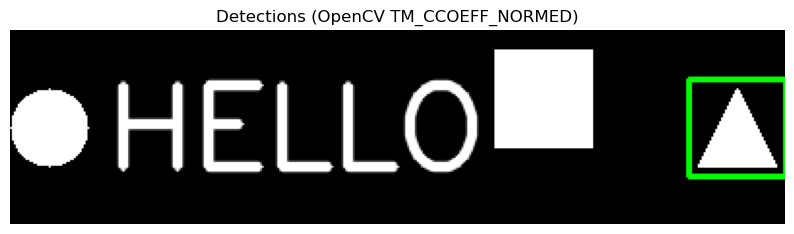

In [72]:
# === CELL 7: REFERENCE WITH OPENCV ===
vis_cv2 = cv2.cvtColor(scene, cv2.COLOR_GRAY2BGR)

H, W = scene.shape
print()

for name, tmpl in templates.items():
    if tmpl is None:
        print(f"[CV2]       {name:>8s} : skipped (template is None)")
        continue

    if tmpl.dtype != np.uint8:
        tmpl = tmpl.astype(np.uint8)

    h, w = tmpl.shape
    if h > H or w > W:
        print(f"[CV2]       {name:>8s} : skipped "
              f"(template {w}x{h} larger than scene {W}x{H})")
        continue

    res = cv2.matchTemplate(scene, tmpl, cv2.TM_CCOEFF_NORMED)

    thr = per_thr.get(name, 0.70)
    md  = max(tmpl.shape) // 3

    peaks = ncc_peaks(res, tmpl.shape, thr=thr, min_dist=md)
    print(f"[CV2]       {name:>8s} : {len(peaks):2d} match(es)")

    vis_cv2 = draw_boxes(scene, peaks, tmpl.shape, color=(0,255,0), thick=2)

imshow_bgr(vis_cv2, "Detections (OpenCV TM_CCOEFF_NORMED)", size=10)


In [73]:
# === CELL 8: SAVE OUTPUTS ===
OUT = ROOT / "out"
OUT.mkdir(exist_ok=True)

p1 = OUT / "detections_numpy.png"
p2 = OUT / "detections_opencv.png"

cv2.imwrite(str(p1), vis_numpy)
cv2.imwrite(str(p2), vis_cv2)

print("Saved:", p1.name, "and", p2.name, "in", OUT)


Saved: detections_numpy.png and detections_opencv.png in C:\Users\sera\Documents\UAB\Computer Vision\out


[NCC NumPy] Circle   :   0 match(es)
[NCC NumPy] E        :   0 match(es)
[NCC NumPy] example  :   1 match(es)
[NCC NumPy] H        :   1 match(es)
[NCC NumPy] L        :   0 match(es)
[NCC NumPy] O        :   1 match(es)
[NCC NumPy] Square   :   0 match(es)
[NCC NumPy] Triangle :   1 match(es)


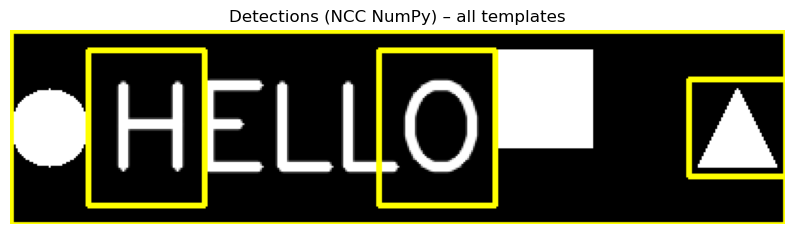

In [74]:
# === CELL 9: RUN NCC ON ALL TEMPLATES ===
def ncc_numpy(scene, tmpl):
    return cv2.matchTemplate(scene, tmpl, cv2.TM_CCOEFF_NORMED)

def match_map(ncc, thresh):
    ys, xs = np.where(ncc >= thresh)
    pts = [(float(ncc[y, x]), int(x), int(y)) for y, x in zip(ys, xs)]
    pts.sort(key=lambda t: t[0], reverse=True)
    return pts

def nms_pts(raw_pts, tmpl_shape, iou):
    if not raw_pts:
        return []
    th, tw = int(tmpl_shape[0]), int(tmpl_shape[1])
    boxes = np.array([[x, y, x + tw, y + th] for s, x, y in raw_pts], dtype=np.int32)
    scores = np.array([s for s, _, _ in raw_pts], dtype=np.float32)
    kept = non_max_suppression(boxes, probs=scores, overlapThresh=iou)
    kept = kept.astype(int)
    score_map = {tuple(b): float(s) for b, s in zip(boxes, scores)}
    pts = [(score_map[tuple(b)], int(b[0]), int(b[1])) for b in kept]
    pts.sort(key=lambda t: t[0], reverse=True)
    return pts

def draw_boxes(img, matches, tmpl_shape, color=(0,255,255), thick=2):
    if img.ndim == 2 or (img.ndim == 3 and img.shape[2] == 1):
        vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR).copy()
    else:
        vis = img.copy()
    th, tw = int(tmpl_shape[0]), int(tmpl_shape[1])
    for s, x, y in matches:
        cv2.rectangle(vis, (x, y), (x + tw, y + th), color, thick)
    return vis

THRESH  = 0.80
NMS_IOU = 0.40

scene_u8 = scene if scene.dtype == np.uint8 else scene.astype(np.uint8)
vis_all = cv2.cvtColor(scene_u8, cv2.COLOR_GRAY2BGR)

for name, tmpl in templates.items():
    tmpl_u8 = tmpl if tmpl.dtype == np.uint8 else tmpl.astype(np.uint8)
    ncc = ncc_numpy(scene_u8, tmpl_u8)
    raw_pts = match_map(ncc, THRESH)
    pts = nms_pts(raw_pts, tmpl_u8.shape, NMS_IOU)
    print(f"[NCC NumPy] {name:<8} : {len(pts):3d} match(es)")
    vis_all = draw_boxes(vis_all, pts, tmpl_u8.shape, color=(0,255,255), thick=2)

imshow_bgr(vis_all, "Detections (NCC NumPy) – all templates", size=10)


[CV2] Circle   : 0 match(es)
[CV2] E        : 0 match(es)
[CV2] example  : 1 match(es)
[CV2] H        : 1 match(es)
[CV2] L        : 0 match(es)
[CV2] O        : 1 match(es)
[CV2] Square   : 0 match(es)
[CV2] Triangle : 1 match(es)


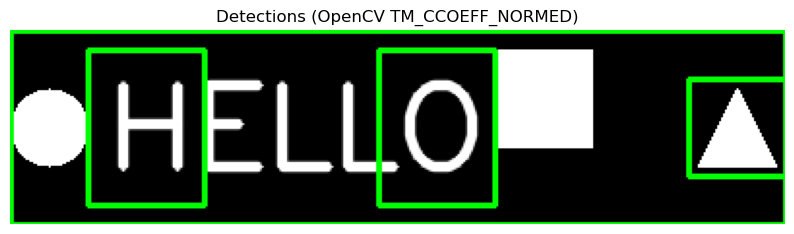

In [75]:
# === CELL 10: OpenCV comparison ===
def cv2_match_template(scene_u8, tmpl_u8, thresh=0.8):
    res = cv2.matchTemplate(scene_u8, tmpl_u8, cv2.TM_CCOEFF_NORMED)
    ys, xs = np.where(res >= thresh)
    raw_pts = [(float(res[y, x]), int(x), int(y)) for y, x in zip(ys, xs)]
    raw_pts.sort(key=lambda t: t[0], reverse=True)
    return raw_pts, res 

viz_cv2 = cv2.cvtColor(scene_u8, cv2.COLOR_GRAY2BGR)

for name, tmpl in templates.items():
    tmpl_u8 = tmpl if tmpl.dtype == np.uint8 else tmpl.astype(np.uint8)
    raw_pts, heat = cv2_match_template(scene_u8, tmpl_u8, THRESH)
    pts_cv2 = nms_pts(raw_pts, tmpl_u8.shape, NMS_IOU) 
    print(f"[CV2] {name:<8} : {len(pts_cv2)} match(es)")
    viz_cv2 = draw_boxes(viz_cv2, pts_cv2, tmpl_u8.shape, color=(0,255,0), thick=2)

imshow_bgr(viz_cv2, "Detections (OpenCV TM_CCOEFF_NORMED)", size=10)


**Questions that must be included in your Report**.

Answer the questions briefly and directly, including the images obtained from the execution of your code to explain your conclusions. Answers must be connected to the executed code.

9. What is the goal of template matching in computer vision?
Briefly describe the purpose and typical applications of template matching.

10. Explain the role of Normalized Cross-Correlation (NCC) in template matching. Why is normalization important in comparing image regions and templates?

11. In your own words, explain the meaning of an NCC value of 1, 0, and -1.
What does each of these values indicate about the similarity between the image region and the template? Relate your answers to your output results.